In [1]:
from matplotlib import pyplot as plt
from itertools import product
import seaborn as sns
import numpy as np
import pandas as pd
import os.path as op
import argparse
import re
from scipy import signal, stats
from sklearn.linear_model import LinearRegression
from statsmodels.stats.multitest import fdrcorrection

In [2]:
spectrums = pd.read_csv('spectrums.csv')
accuracy = pd.read_csv('accuracy.csv', index_col = 0)

# Add accuracy group to dataframe
accuracy = accuracy.rename(columns = {'sub_num': 'subject', 'score_group' : 'group'})
spectrums = spectrums.merge(accuracy, left_on = ["subject"], right_on = ["subject"])
np.unique(spectrums.subject)

array([ 3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 18, 19, 20,
       21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37,
       38, 39, 40, 41, 42, 43, 44, 45])

In [3]:
palette_tab10 = sns.color_palette("tab10", 10)

### Just FFRs

In [4]:
spectrums_sub = spectrums.groupby(['subject', 'stimulus', 'frequency'], as_index=False)['power'].mean()
spectrums_sub

,subject,stimulus,frequency,power
0,3,130,0.000000,10.870513
1,3,130,4.979253,10.824909
2,3,130,9.958506,11.347983
3,3,130,14.937759,10.709099
4,3,130,19.917012,10.824084
...,...,...,...,...
15241,45,280,577.593361,2.088504
15242,45,280,582.572614,0.254580
15243,45,280,587.551867,-0.184774
15244,45,280,592.531120,0.306909


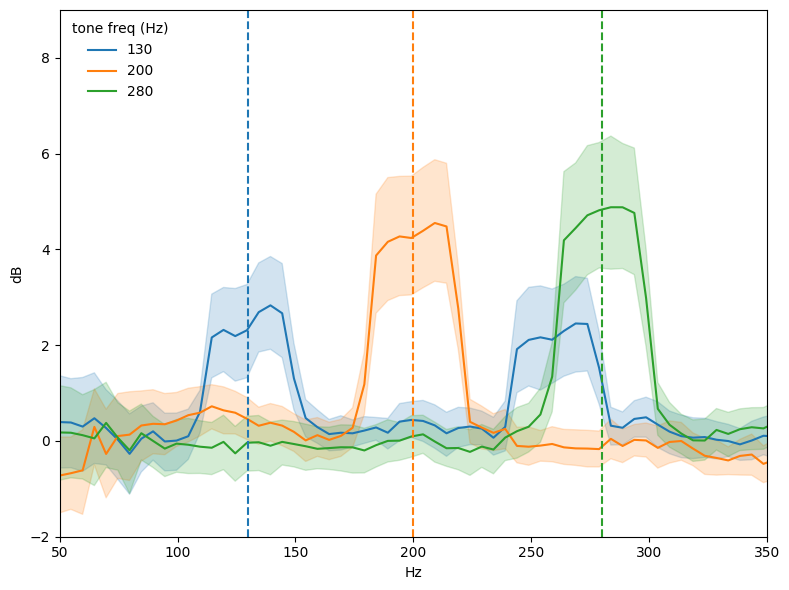

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
spectrums_sub = spectrums.groupby(['subject', 'stimulus', 'frequency'], as_index=False)['power'].mean()
graph = sns.lineplot(data = spectrums_sub, x = "frequency", y = "power", hue = "stimulus", palette = 'tab10', ax = ax)
graph.axvline(130, linestyle = 'dashed', color = palette_tab10[0])
graph.axvline(200, linestyle = 'dashed', color = palette_tab10[1])
graph.axvline(280, linestyle = 'dashed', color = palette_tab10[2])
graph.set_ylabel("dB")
graph.set_xlabel("Hz")
graph.set_xlim(50, 350)
graph.set_ylim(-2, 9)
plt.legend(frameon=False, title = 'tone freq (Hz)', loc = 'upper left')
plt.tight_layout()
# plt.savefig('../figs/FFR.png', dpi = 300)

### By accuracy

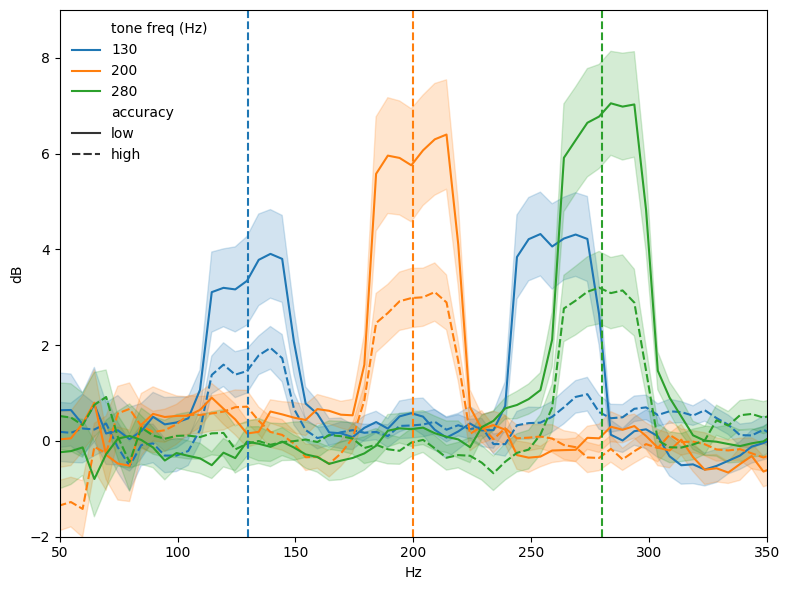

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
spectrums_accuracy = spectrums.copy()
spectrums_accuracy['tone freq (Hz)'] = spectrums_accuracy.stimulus
spectrums_accuracy['accuracy'] = spectrums_accuracy.group
spectrums_accuracy = spectrums_accuracy.groupby(['subject', 'frequency', 'tone freq (Hz)', 'accuracy'], as_index=False)['power'].mean()
graph = sns.lineplot(data = spectrums_accuracy, x = "frequency", y = "power", hue = "tone freq (Hz)", style = "accuracy", palette = 'tab10', errorbar = 'se', ax = ax)
graph.axvline(130, linestyle = 'dashed', color = palette_tab10[0])
graph.axvline(200, linestyle = 'dashed', color = palette_tab10[1])
graph.axvline(280, linestyle = 'dashed', color = palette_tab10[2])
graph.set_ylabel("dB")
graph.set_xlabel("Hz")
graph.set_xlim(50, 350)
graph.set_ylim(-2, 9)
plt.legend(frameon=False, loc = 'upper left')
plt.tight_layout()
# plt.savefig('../figs/FFR-by-accuracy.png', dpi = 300)

## Values and Tests

In [14]:
from statsmodels.stats.anova import AnovaRM, anova_lm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

#### By accuracy

In [15]:
spectrums_sub = spectrums.groupby(['subject', 'stimulus', 'frequency', 'group'], as_index=False)['power'].mean()

In [16]:
# Take only power at stim freq
power_f0 = pd.DataFrame()
stimuli = [130, 200, 280]
for stim in stimuli:
    idx = np.abs(spectrums_sub.frequency - stim).argmin()
    hz = spectrums_sub.frequency[idx]
    stim_spectrum = spectrums_sub[spectrums_sub.frequency == hz]
    stim_spectrum = stim_spectrum[stim_spectrum.stimulus == stim]
    power_f0 = pd.concat([power_f0, stim_spectrum])
power_f0 = power_f0.reset_index(drop = True)
power_f0

,subject,stimulus,frequency,group,power
0,3,130,129.460581,low,5.445221
1,4,130,129.460581,high,5.068257
2,5,130,129.460581,low,7.184012
3,6,130,129.460581,high,1.639965
4,7,130,129.460581,low,2.900680
...,...,...,...,...,...
121,41,280,278.838174,high,5.187242
122,42,280,278.838174,low,7.642388
123,43,280,278.838174,high,-4.837921
124,44,280,278.838174,low,5.044214


In [17]:
descriptives = power_f0.groupby(['stimulus', 'group'], as_index=False)['power'].mean()
descriptives['sd'] = power_f0.groupby(['stimulus', 'group'], as_index=False)['power'].std().power
descriptives['se'] = descriptives.sd/np.sqrt(28)
descriptives['95CIlower'] = descriptives.power - descriptives.se*1.96
descriptives['95CIupper'] = descriptives.power + descriptives.se*1.96
descriptives

,stimulus,group,power,sd,se,95CIlower,95CIupper
0,130,high,1.460188,2.218810,0.419316,0.638329,2.282047
1,130,low,3.343189,4.036292,0.762787,1.848126,4.838252
2,200,high,2.983849,2.969946,0.561267,1.883765,4.083932
3,200,low,5.757179,5.147146,0.972719,3.850650,7.663709
4,280,high,3.201097,3.630308,0.686064,1.856412,4.545782
5,280,low,6.774855,4.744036,0.896539,5.017639,8.532071


<Axes: xlabel='stimulus', ylabel='power'>

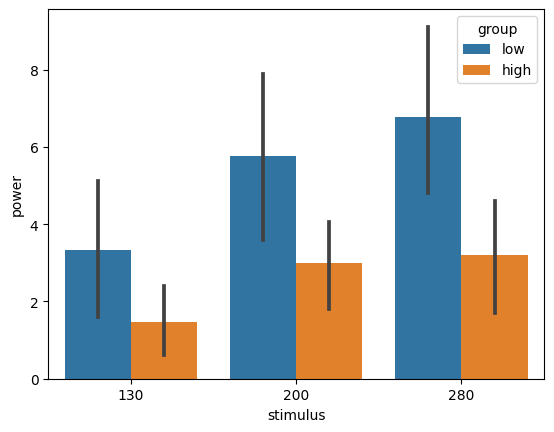

In [18]:
sns.barplot(power_f0, hue = 'group', x = 'stimulus', y = 'power')

In [19]:
power_f0_130 = power_f0[power_f0.stimulus == 130]
t, p1 = stats.ttest_ind(power_f0_130.power[power_f0_130.group == 'low'], power_f0_130.power[power_f0_130.group == 'high'])
print(t, p1)

power_f0_200 = power_f0[power_f0.stimulus == 200]
t, p2 = stats.ttest_ind(power_f0_200.power[power_f0_200.group == 'low'], power_f0_200.power[power_f0_200.group == 'high'])
print(t, p2)

power_f0_280 = power_f0[power_f0.stimulus == 280]
t, p3 = stats.ttest_ind(power_f0_280.power[power_f0_280.group == 'low'], power_f0_280.power[power_f0_280.group == 'high'])
print(t, p3)

rejected, corrected_ps = fdrcorrection([p1, p2, p3], alpha=0.05)
print(rejected, corrected_ps)

1.9170010438911127 0.0624003016953731
2.1842862605472595 0.034862749326800474
2.7654397103146438 0.00855947141954922
[False False  True] [0.0624003  0.05229412 0.02567841]


In [20]:
formula = 'power ~ C(stimulus) + C(group) + C(stimulus):C(group)'
model = ols(formula, data = power_f0).fit()
anova_table = anova_lm(model, typ=2)
print(anova_table)

# Perform the Tukey HSD post-hoc test if the ANOVA results are significant
if any(p < 0.05 for p in anova_table['PR(>F)'][:-1]):
    m_comp = pairwise_tukeyhsd(power_f0.power, 
                              power_f0[[factor for factor in ['stimulus', 'group'] if factor in power_f0]].apply(lambda x: '-'.join(x.astype(str)), axis=1), 
                              alpha=0.05)
    print(m_comp)
else:
    print("No significant effect found, post-hoc test not performed.")

                           sum_sq     df          F    PR(>F)
C(stimulus)            144.559516    2.0   4.907160  0.008944
C(group)               234.920043    1.0  15.949004  0.000113
C(stimulus):C(group)    14.885853    2.0   0.505309  0.604597
Residual              1767.533857  120.0        NaN       NaN
  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1   group2  meandiff p-adj   lower  upper  reject
-------------------------------------------------------
130-high  130-low    1.883 0.6116  -1.563  5.329  False
130-high 200-high   1.5237 0.7585 -1.7542 4.8015  False
130-high  200-low    4.297 0.0058  0.8509  7.743   True
130-high 280-high   1.7409 0.6404 -1.5369 5.0187  False
130-high  280-low   5.3147 0.0003  1.8686 8.7607   True
 130-low 200-high  -0.3593 0.9997 -3.8054 3.0867  False
 130-low  200-low    2.414  0.384 -1.1924 6.0204  False
 130-low 280-high  -0.1421    1.0 -3.5881  3.304  False
 130-low  280-low   3.4317  0.072 -0.1747 7.0381  False
200-high  200-low 

In [21]:
# get power only at stim f0
stims = [130, 200, 280]
power_f0_only = []

for stim in stims:    
    idx = np.abs(spectrums.frequency - stim).argmin()
    hz = spectrums.frequency[idx]
    power_f0 = spectrums[spectrums.frequency == hz]
    power_f0 = power_f0[power_f0.stimulus == stim]
    power_f0_only.append(power_f0)

power_f0_only = pd.concat(power_f0_only).reset_index(drop = True)
power_f0_only.to_csv('power_f0_only.csv', index = False)
power_f0_only

,subject,target,stimulus,frequency,power,accuracy,group
0,3,130,130,129.460581,2.126778,0.804233,low
1,3,200,130,129.460581,7.821449,0.804233,low
2,3,280,130,129.460581,6.387437,0.804233,low
3,4,130,130,129.460581,3.763498,0.961423,high
4,4,200,130,129.460581,4.520233,0.961423,high
...,...,...,...,...,...,...,...
373,44,200,280,278.838174,6.061416,0.902753,low
374,44,280,280,278.838174,5.798800,0.902753,low
375,45,130,280,278.838174,-0.807070,0.979403,high
376,45,200,280,278.838174,1.511245,0.979403,high


In [22]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

formula = 'power ~ C(stimulus) + C(group) + C(stimulus):C(group)'
model = ols(formula, data = power_f0_only).fit()
anova_table = anova_lm(model, typ=2)
print(anova_table)

# Perform the Tukey HSD post-hoc test if the ANOVA results are significant
if any(p < 0.05 for p in anova_table['PR(>F)'][:-1]):
    m_comp = pairwise_tukeyhsd(power_f0_only.power, 
                              power_f0_only[[factor for factor in ['stimulus', 'group'] if factor in power_f0_only]].apply(lambda x: '-'.join(x.astype(str)), axis=1), 
                              alpha=0.05)
    print(m_comp)
else:
    print("No significant effect found, post-hoc test not performed.")

                           sum_sq     df          F        PR(>F)
C(stimulus)            433.678549    2.0  11.795928  1.078900e-05
C(group)               704.760130    1.0  38.338532  1.574091e-09
C(stimulus):C(group)    44.657558    2.0   1.214672  2.979817e-01
Residual              6838.310081  372.0        NaN           NaN
  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
 group1   group2  meandiff p-adj   lower   upper  reject
--------------------------------------------------------
130-high  130-low    1.883 0.1409 -0.3153  4.0813  False
130-high 200-high   1.5237 0.2961 -0.5674  3.6147  False
130-high  200-low    4.297    0.0  2.0986  6.4953   True
130-high 280-high   1.7409 0.1642 -0.3501   3.832  False
130-high  280-low   5.3147    0.0  3.1163   7.513   True
 130-low 200-high  -0.3593 0.9972 -2.5577   1.839  False
 130-low  200-low    2.414 0.0334  0.1133  4.7146   True
 130-low 280-high  -0.1421    1.0 -2.3404  2.0563  False
 130-low  280-low   3.4317 0.0004   1.131  

In [23]:
m_comp = pairwise_tukeyhsd(power_f0.power, 
                          power_f0[[factor for factor in ['stimulus'] if factor in power_f0]].apply(lambda x: '-'.join(x.astype(str)), axis=1), 
                          alpha=0.05)
print(m_comp)

ValueError: 2 or more groups required for multiple comparisons

#### By accuracy and target

In [ ]:
# get power at f0
stims = [130, 200, 280]
power_f0_only = []

for stim in stims:    
    idx = np.abs(spectrums.frequency - stim).argmin()
    hz = spectrums.frequency[idx]
    power_f0 = spectrums[spectrums.frequency == hz]
    power_f0_only.append(power_f0)

power_f0_only = pd.concat(power_f0_only).reset_index(drop = True)
power_f0_only

In [ ]:
# get power only at stim f0
stims = [130, 200, 280]
power_f0_only = []

for stim in stims:    
    idx = np.abs(spectrums.frequency - stim).argmin()
    hz = spectrums.frequency[idx]
    power_f0 = spectrums[spectrums.frequency == hz]
    power_f0 = power_f0[power_f0.stimulus == stim]
    power_f0_only.append(power_f0)

power_f0_only = pd.concat(power_f0_only).reset_index(drop = True)
power_f0_only

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

formula = 'power ~ C(stimulus) + C(group) + C(stimulus):C(group)'
model = ols(formula, data = power_f0_only).fit()
anova_table = anova_lm(model, typ=2)
print(anova_table)

# Perform the Tukey HSD post-hoc test if the ANOVA results are significant
if any(p < 0.05 for p in anova_table['PR(>F)'][:-1]):
    m_comp = pairwise_tukeyhsd(power_f0_only.power, 
                              power_f0_only[[factor for factor in ['stimulus', 'group'] if factor in power_f0_only]].apply(lambda x: '-'.join(x.astype(str)), axis=1), 
                              alpha=0.05)
    print(m_comp)
else:
    print("No significant effect found, post-hoc test not performed.")

In [ ]:
# # Factor in targets
# formula = 'power ~ C(stimulus) + C(target) + C(group) + C(stimulus):C(target) + C(stimulus):C(group) + C(group):C(target) + C(stimulus):C(target):C(group)'
# model = ols(formula, data = power_f0_only).fit()
# anova_table = anova_lm(model, typ=2)
# print(anova_table)

# # Perform the Tukey HSD post-hoc test if the ANOVA results are significant
# if any(p < 0.05 for p in anova_table['PR(>F)'][:-1]):
#     m_comp = pairwise_tukeyhsd(power_f0_only.power, 
#                               power_f0_only[[factor for factor in ['stimulus', 'target', 'group'] if factor in power_f0_only]].apply(lambda x: '-'.join(x.astype(str)), axis=1), 
#                               alpha=0.05)
#     print(m_comp)
# else:
#     print("No significant effect found, post-hoc test not performed.")

In [ ]:
# get power at f0 and first harmonic
stims = [130, 200, 280]
power_f0_only = []

for stim in stims:    
    idx = np.abs(spectrums.frequency - target_freq).argmin()
    hz = spectrums.frequency[idx]
    idx = np.abs(spectrums.frequency - target_freq*2).argmin()
    hz_harmonic1 = spectrums.frequency[idx]
    power_f0 = spectrums[(spectrums.frequency == hz) | (spectrums.frequency == hz_harmonic1)]
    power_f0 = power_f0[power_f0.stim == stim]
#     power_f0 = power_f0.groupby(['subject', 'target', 'stim', 'group'], as_index=False).accuracy.mean()

#     power_f0_only.append(power_f0)
# power_f0_only = pd.concat(power_f0_only)

## Regressions

In [ ]:
# graph = sns.lmplot(data = power_f0_only, x = "accuracy", y = "power", hue = "stimulus", legend = False)

# # 130 Hz tone
# power_f0_130 = power_f0_only[power_f0_only.stimulus == 130]
# # sns.regplot(data = power_f0_130, x="accuracy", y="power")
# slope, intercept, r_value, p_value, std_err = stats.linregress(power_f0_130.accuracy, power_f0_130.power)
# print(slope, intercept, r_value, p_value, std_err)

# # 200 Hz tone
# power_f0_200 = power_f0_only[power_f0_only.stimulus == 200]
# sns.regplot(data = power_f0_200, x="accuracy", y="power")
# slope, intercept, r_value, p_value, std_err = stats.linregress(power_f0_200.accuracy, power_f0_200.power)
# print(slope, intercept, r_value, p_value, std_err)

# # 280 Hz tone
# power_f0_280 = power_f0_only[power_f0_only.stimulus == 280]
# sns.regplot(data = power_f0_280, x="accuracy", y="power")
# slope, intercept, r_value, p_value, std_err = stats.linregress(power_f0_280.accuracy, power_f0_280.power)
# print(slope, intercept, r_value, p_value, std_err)

# MANOVA

In [ ]:
import pingouin as pg

In [ ]:
spectrums = pd.read_csv('spectrums.csv')
accuracy = pd.read_csv('accuracy.csv', index_col = 0)

# Add accuracy group to dataframe
accuracy = accuracy.rename(columns = {'sub_num': 'subject', 'score_group' : 'group'})
spectrums = spectrums.merge(accuracy, left_on = ["subject"], right_on = ["subject"])
np.unique(spectrums.subject)

In [ ]:
spectrums

In [ ]:
spectrums_sub = spectrums.groupby(['subject', 'stimulus', 'frequency', 'target', 'group'], as_index=False)['power'].mean()

In [ ]:
power_f0 = pd.DataFrame()
stimuli = [130, 200, 280]
for stim in stimuli:
    idx = np.abs(spectrums_sub.frequency - stim).argmin()
    hz = spectrums_sub.frequency[idx]
    stim_spectrum = spectrums_sub[spectrums_sub.frequency == hz]
    # stim_spectrum = stim_spectrum[stim_spectrum.stimulus == stim]
    power_f0 = pd.concat([power_f0, stim_spectrum])
power_f0 = power_f0.reset_index(drop = True)
# power_f0

In [ ]:
aov = pg.mixed_anova(data=power_f0, dv='power', within=['stimulus', 'frequency', 'target'], between='group', subject='subject')
print(aov)

In [ ]:
power_f0.to_csv('power_f0_with_accuracies.csv', index = False)